In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [34]:
data = pd.read_csv(r"/Users/siddhu/Desktop/Programs/Machine Learning/EX6/introvert or extrovert.csv")
data.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4,No,8.0,5.0,Extrovert


In [35]:
print(data.isnull().sum())

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


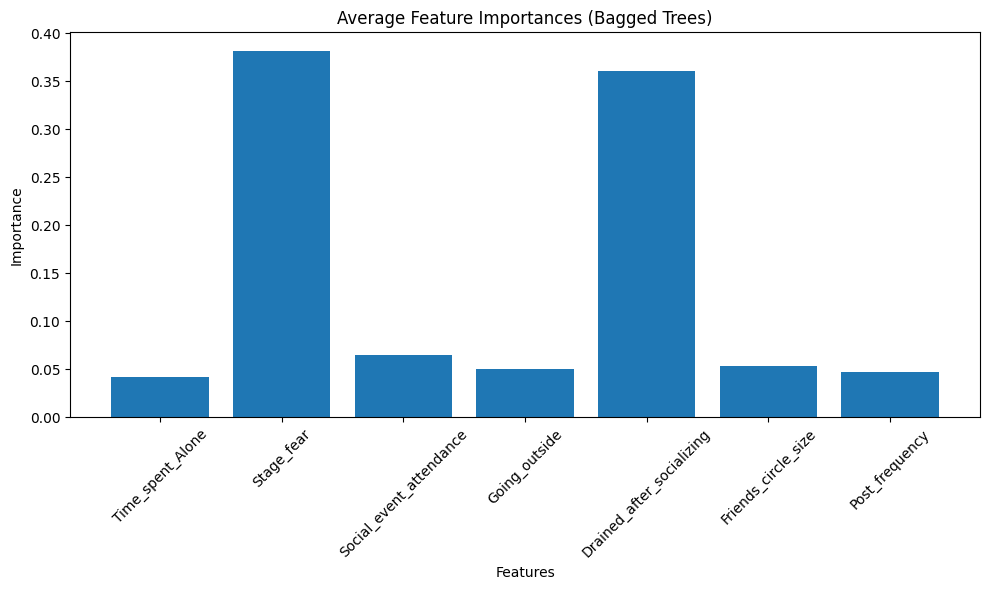

In [36]:
# Average feature importances across all trees
feature_importances = np.mean([
    tree.feature_importances_ for tree in bag_model.estimators_
], axis=0)

# Plot
plt.figure(figsize=(10,6))
plt.bar(X.columns, feature_importances)
plt.xticks(rotation=45)
plt.title("Average Feature Importances (Bagged Trees)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [37]:
label_encoders = {}
for column in data.columns:
    data[column] = data[column].astype(str)
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

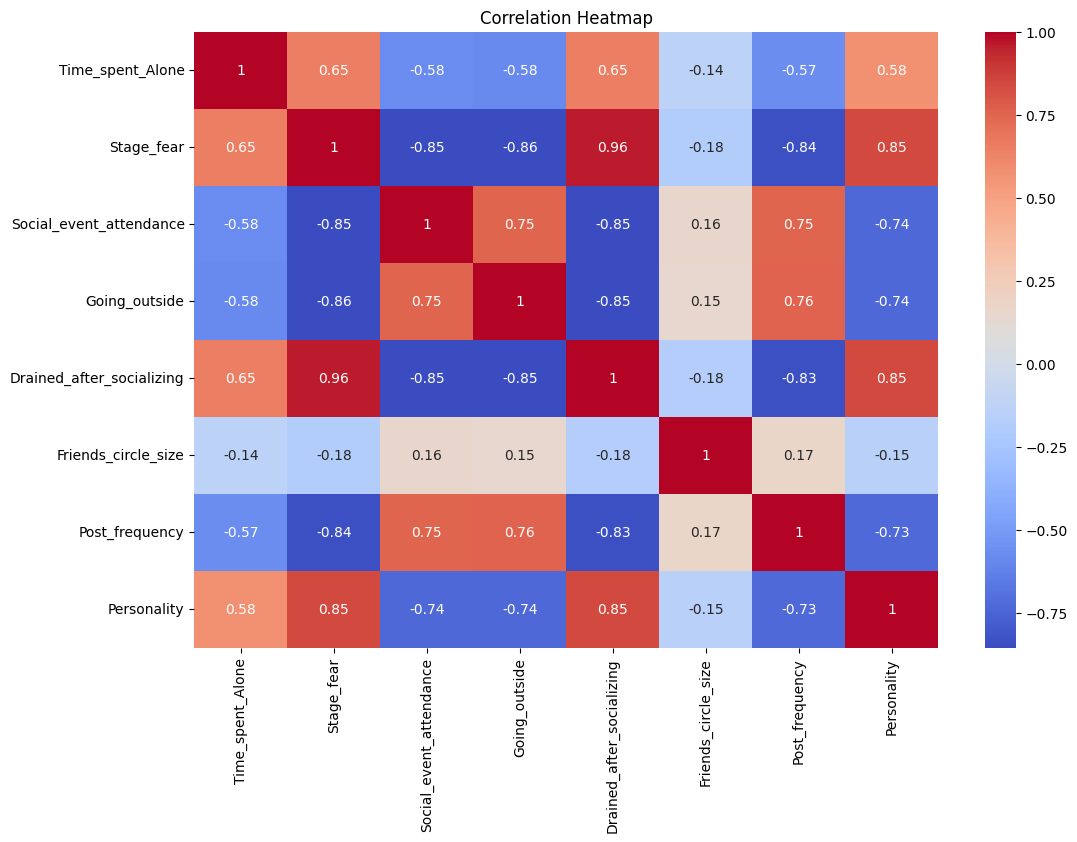

In [38]:
plt.figure(figsize =(12,8))
sns.heatmap(data.corr(numeric_only = True),annot = True, cmap ='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
X = data.drop('Personality', axis=1)  # Replace al' with your label column
y = data['Personality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [40]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [41]:
n_range = range(1, 31)
accuracies = []

for n in n_range:
    bag_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        max_samples=0.8,
        bootstrap=True,
        random_state=42
    )
    bag_model.fit(X_train, y_train)
    y_pred = bag_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)



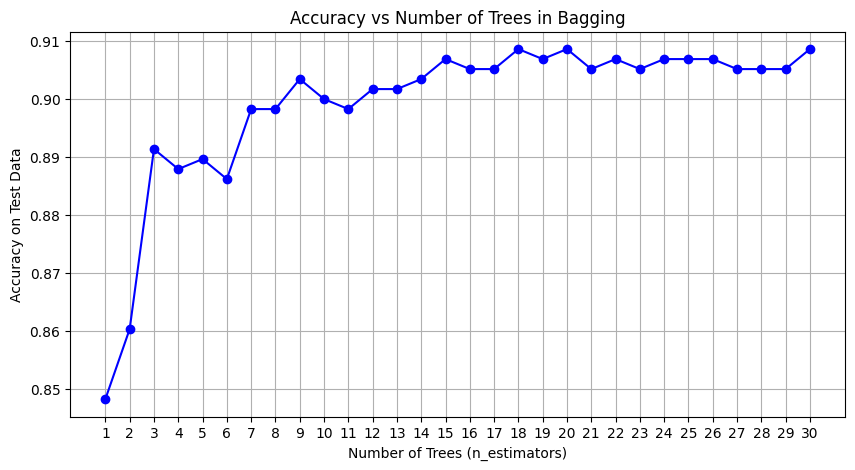

Best number of trees = 18 with accuracy = 0.9086


In [42]:
# Plotting the line graph
plt.figure(figsize=(10, 5))
plt.plot(n_range, accuracies, marker='o', linestyle='-', color='b')
plt.title("Accuracy vs Number of Trees in Bagging")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy on Test Data")
plt.grid(True)
plt.xticks(n_range)
plt.show()

# Best number of trees
best_n = n_range[accuracies.index(max(accuracies))]
print(f"Best number of trees = {best_n} with accuracy = {max(accuracies):.4f}")


In [43]:
# Predict using both models
dt_pred = dt_model.predict(X_test)
bag_pred = bag_model.predict(X_test)

# Calculate accuracies
dt_acc = accuracy_score(y_test, dt_pred)
bag_acc = accuracy_score(y_test, bag_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Bagging Classifier Accuracy:", bag_acc)

Decision Tree Accuracy: 0.8689655172413793
Bagging Classifier Accuracy: 0.9086206896551724


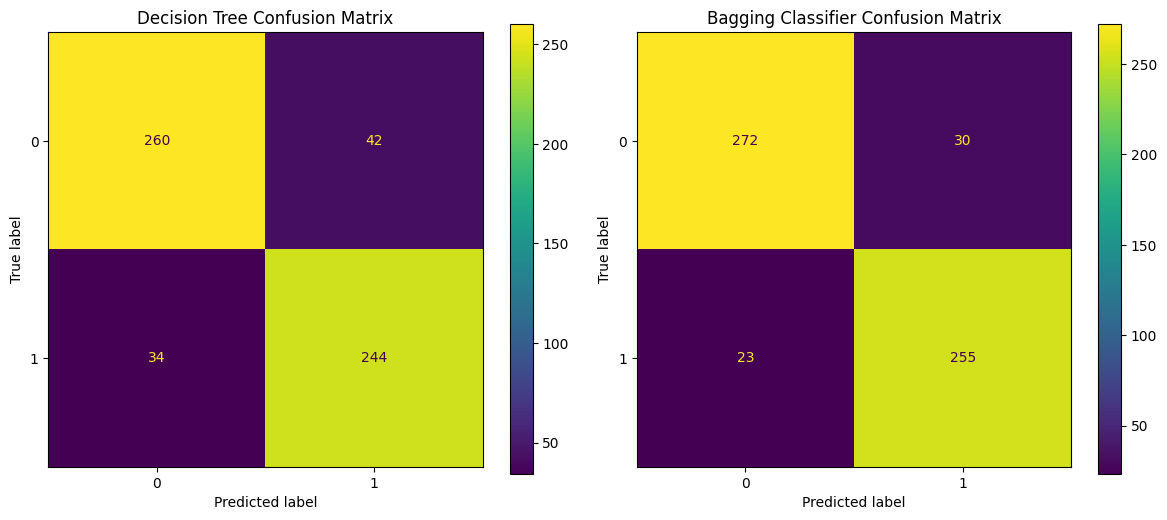

In [44]:
dt_cm = confusion_matrix(y_test, dt_pred)
bag_cm = confusion_matrix(y_test, bag_pred)

# Plotting both confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(dt_cm).plot(ax=axes[0])
axes[0].set_title("Decision Tree Confusion Matrix")

ConfusionMatrixDisplay(bag_cm).plot(ax=axes[1])
axes[1].set_title("Bagging Classifier Confusion Matrix")

plt.tight_layout()
plt.show()
